1. Derive the retention table first (the foundation)

Join activity_log → users on user_id
Compute week_since_signup = (workout_logged_date - signup_date).days // 7
Collapse to a boolean: was the user active at all in week N (since a user can have multiple workout logs in one week)
Decide and document your week-bucketing convention (e.g., does week 0 = signup week, or does week 1 start the day after signup?) — this exact ambiguity is a common "gotcha" in SQL retention interview questions

2. N-day vs. rolling retention, by channel

N-day: % active in exactly week N
Rolling: % active in week N or any week after
Compare the two — rolling will always be ≥ N-day; if it isn't, you have a bug
This is the core deliverable — practice explaining when you'd use each (N-day for "is this specific week healthy," rolling for "have they truly churned")

3. Handle the observation-window problem (real PA skill, often skipped by beginners)

Newer cohorts haven't had 8 weeks elapse yet (snapshot cutoff is 2024-03-15) — you must compute max_observable_week per user from their signup_date, and exclude weeks that haven't happened yet from your denominator
This is a classic mistake that makes "retention" look artificially bad for recent cohorts if you don't handle it — flagging this correctly is a strong signal in an interview

4. Retention curve by channel — and the "why," not just the "what"

Plot week 1-8 retention per channel
Identify which channel: (a) has the best long-term retention, (b) just looks good early then craters (classic paid/social pattern), (c) is noisiest/most volatile (small sample, real-world messiness)
Write one sentence per channel — that's your "business interpretation," the part that actually matters to a VP

5. Spot the anomaly and the seasonality (the hard part, on purpose)

Compare cohorts against each other on week-1 retention — one cohort should stand out badly (the outage). Ask: is this channel-driven or cohort-specific? (It's cohort-specific → operational issue, not an acquisition-quality issue — different action for the business)
Check whether retention bumps correlate with calendar date rather than weeks-since-signup — that's the seasonality trap. This directly maps to the "distinguish user fatigue from seasonal effects" requirement from the original prompt, and it's a genuinely good interview story ("I noticed a bump that wasn't really about the channel, it was calendar-driven — here's how I caught it")

6. The FitTrack framing — tie it to the actual business ask

The VP wants unit economics + Series B fundraising story. So beyond just charting curves, practice writing: "Channel X shows strong week-1 signup volume but retention drops below Y% by week 4 — reallocating spend toward channel Z, which retains at 2x the rate by week 8, would improve the acquisition ROI story for investors."
This "so what for the business" sentence is the actual differentiator in interviews — anyone can make a chart, fewer people connect it to budget/roadmap decisions.

# Cohorts

context : 
You are a Senior Product Analyst at FitTrack, a fast-growing mobile app company that provides fitness tracking and wellness coaching. Over the past year, FitTrack has grown from 100K to 500K monthly active users through various acquisition campaigns and feature launches. However, this rapid growth has created analytical blind spots.

The product team has been running A/B tests on new features while the marketing team experiments with different acquisition channels. Both teams collect data, but nobody has connected the dots between user acquisition quality, behavioral patterns, and long-term retention. Leadership suspects that some acquisition channels bring users who churn quickly, while certain user segments might be more valuable than others.

The VP of Product has asked you to conduct a comprehensive analysis that unifies these insights. She needs evidence-based recommendations to optimize both user acquisition strategy and product features. The stakes are high—FitTrack is preparing for Series B fundraising in Q2 and needs to demonstrate strong unit economics and user engagement metrics to investors. Your analysis will directly inform a $2M marketing budget reallocation and influence product roadmap priorities for the next six months.

### cohort checklist

Build a retention analysis system that calculates both N-day and rolling retention metrics. Process the cohort data to compute 1-day, 3-day, 7-day, 14-day, and 30-day retention rates for each acquisition channel. Compare the results between N-day (exact day return) and rolling (return on or after) calculations.

Create visualizations showing retention curves by acquisition channel and identify which channels deliver the highest-quality users based on long-term engagement patterns.

In [76]:
import pandas as pd
import numpy as np 
import duckdb

In [77]:
con = duckdb.connect()

con.execute("""
    CREATE TABLE users AS 
    SELECT * FROM read_csv_auto('data/users.csv')
""")

con.execute("""
    CREATE TABLE activity AS 
    SELECT * FROM read_csv_auto('data/activity_log.csv')
""")

print("Tables loaded:")
print(con.execute("SHOW TABLES").df())

Tables loaded:
       name
0  activity
1     users


In [78]:
con.execute("SELECT max(signup_date) as max , min(signup_date) as min FROM users LIMIT 5").df()

,max,min
0,2024-03-24,2024-01-01


In [79]:
con.execute("SELECT max(workout_logged_date) as max_date, min(workout_logged_date) as min_date FROM activity").df()

,max_date,min_date
0,2024-03-15,2024-01-08


In [80]:
# now we have to crate n day retention :
# we will first split the activity log dataset into weeks and then count workputs logged epr week 
# then we join this to the uers dataset ( only using weeks as the dataset is only for 2024)
#
#

In [81]:
con.execute("""
WITH activity_with_week AS (
    SELECT user_id as user_id2,week(workout_logged_date) as week_logged_date
    , count(*) as workouts_per_week
    FROM activity
    GROUP BY user_id, week(workout_logged_date) 
    order by user_id , week(workout_logged_date)
)
select * from activity_with_week
""").df()

,user_id2,week_logged_date,workouts_per_week
0,USER_200001,2,2
1,USER_200001,3,1
2,USER_200001,7,3
3,USER_200001,8,1
4,USER_200002,3,3
...,...,...,...
10247,USER_204800,11,1
10248,USER_204801,11,1
10249,USER_204803,11,1
10250,USER_204805,11,1


In [82]:
con.execute("""
WITH activity_with_week AS (
    SELECT user_id as user_id2,week(workout_logged_date) as week_logged_date, count(*) as workouts_per_week
    FROM activity
    GROUP BY user_id, week(workout_logged_date) 
    order by user_id , week(workout_logged_date)
)
select *, week(signup_date) as week_signup_cohortindex from users 
left join activity_with_week on users.user_id = activity_with_week.user_id2
order by users.user_id, activity_with_week.week_logged_date
""").df()

,user_id,signup_date,acquisition_channel,user_id2,week_logged_date,workouts_per_week,week_signup_cohortindex
0,USER_200001,2024-01-07,paid_search,USER_200001,2,2,1
1,USER_200001,2024-01-07,paid_search,USER_200001,3,1,1
2,USER_200001,2024-01-07,paid_search,USER_200001,7,3,1
3,USER_200001,2024-01-07,paid_search,USER_200001,8,1,1
4,USER_200002,2024-01-01,email,USER_200002,3,3,1
...,...,...,...,...,...,...,...
11892,USER_205855,2024-03-19,paid_search,NaN,<NA>,<NA>,12
11893,USER_205856,2024-03-22,organic,NaN,<NA>,<NA>,12
11894,USER_205857,2024-03-20,referral,NaN,<NA>,<NA>,12
11895,USER_205858,2024-03-18,paid_search,NaN,<NA>,<NA>,12


In [83]:
con.execute("""
with joined_table as (
WITH activity_with_week AS (
    SELECT user_id as user_id2,week(workout_logged_date) as week_logged_date, count(*) as workouts_per_week
    FROM activity
    GROUP BY user_id, week(workout_logged_date) 
    order by user_id , week(workout_logged_date)
)
select *, week(signup_date) as week_signup_cohortindex from users 
left join activity_with_week on users.user_id = activity_with_week.user_id2
order by users.user_id, activity_with_week.week_logged_date
)
-- select *  from joined_table   
select user_id , acquisition_channel , week_logged_date , week_signup_cohortindex from joined_table
""").df()

,user_id,acquisition_channel,week_logged_date,week_signup_cohortindex
0,USER_200001,paid_search,2,1
1,USER_200001,paid_search,3,1
2,USER_200001,paid_search,7,1
3,USER_200001,paid_search,8,1
4,USER_200002,email,3,1
...,...,...,...,...
11892,USER_205855,paid_search,<NA>,12
11893,USER_205856,organic,<NA>,12
11894,USER_205857,referral,<NA>,12
11895,USER_205858,paid_search,<NA>,12


In [84]:
con.execute("""
with joined_table as (
WITH activity_with_week AS (
    SELECT user_id as user_id2,week(workout_logged_date) as week_logged_date, count(*) as workouts_per_week
    FROM activity
    GROUP BY user_id, week(workout_logged_date) 
    order by user_id , week(workout_logged_date)
)
select *, week(signup_date) as week_signup_cohortindex from users 
left join activity_with_week on users.user_id = activity_with_week.user_id2
order by users.user_id, activity_with_week.week_logged_date
)
select * from joined_table 
""").df()

,user_id,signup_date,acquisition_channel,user_id2,week_logged_date,workouts_per_week,week_signup_cohortindex
0,USER_200001,2024-01-07,paid_search,USER_200001,2,2,1
1,USER_200001,2024-01-07,paid_search,USER_200001,3,1,1
2,USER_200001,2024-01-07,paid_search,USER_200001,7,3,1
3,USER_200001,2024-01-07,paid_search,USER_200001,8,1,1
4,USER_200002,2024-01-01,email,USER_200002,3,3,1
...,...,...,...,...,...,...,...
11892,USER_205855,2024-03-19,paid_search,NaN,<NA>,<NA>,12
11893,USER_205856,2024-03-22,organic,NaN,<NA>,<NA>,12
11894,USER_205857,2024-03-20,referral,NaN,<NA>,<NA>,12
11895,USER_205858,2024-03-18,paid_search,NaN,<NA>,<NA>,12


In [85]:
# ok so looking at this we should remove the users who signed 
# up after 15th march as we dont have any activyty data
# for them  

In [158]:
nweek_retention= con.execute("""
with joined_table as (
WITH activity_with_week AS (
    SELECT user_id as user_id2,week(workout_logged_date) as week_logged_date, count(*) as workouts_per_week
    FROM activity
    GROUP BY user_id, week(workout_logged_date) 
    order by user_id , week(workout_logged_date)
)
select *, week(signup_date) as week_signup_cohortindex from users 
left join activity_with_week on users.user_id = activity_with_week.user_id2
order by users.user_id, activity_with_week.week_logged_date
)
, totals as (
select 
week_signup_cohortindex, 
count(distinct user_id) as total_signed_up_users
from joined_table
where signup_date <= '2024-03-15'
group by week_signup_cohortindex
)
, base_table as (
select 
user_id , signup_date , (week_logged_date - week_signup_cohortindex ) as week_diff, week_signup_cohortindex 
from joined_table 
where signup_date <= '2024-03-15'
)
-- select * from base_table
select 
week_signup_cohortindex as cohort,
count(distinct user_id) as total,
count(distinct case when week_diff = 1 then user_id end) as week_1,
count(distinct case when week_diff = 2 then user_id end) as week_2,
count(distinct case when week_diff = 3 then user_id end) as week_3,
count(distinct case when week_diff = 4 then user_id end) as week_4,
count(distinct case when week_diff = 5 then user_id end) as week_5,
count(distinct case when week_diff = 6 then user_id end) as week_6,
count(distinct case when week_diff = 7 then user_id end) as week_7,
count(distinct case when week_diff = 8 then user_id end) as week_8,
count(distinct case when week_diff = 9 then user_id end) as week_9
from base_table
group by week_signup_cohortindex
order by week_signup_cohortindex
""").df()


In [159]:
nweek_retention

,cohort,total,week_1,week_2,week_3,week_4,week_5,week_6,week_7,week_8,week_9
0,1,456,356,212,164,124,107,151,159,75,0
1,2,510,383,221,157,125,189,190,105,72,0
2,3,457,349,214,164,187,169,108,86,65,0
3,4,422,326,197,187,174,126,87,64,0,0
4,5,585,452,378,309,168,123,80,0,0,0
5,6,482,316,277,175,122,90,0,0,0,0
6,7,499,438,254,166,110,0,0,0,0,0
7,8,418,298,219,116,0,0,0,0,0,0
8,9,402,310,178,0,0,0,0,0,0,0
9,10,576,380,0,0,0,0,0,0,0,0


In [160]:
week_cols = [c for c in nweek_retention.columns if c.startswith("week_")]
retention_pct = nweek_retention.copy()
retention_pct[week_cols] = (
    nweek_retention[week_cols]
    .div(nweek_retention["total"], axis=0)
    .mul(100)
    .round(1)
    .replace(0, float("nan"))  # zeros are unobserved weeks, not true 0% retention
)
retention_pct

,cohort,total,week_1,week_2,week_3,week_4,week_5,week_6,week_7,week_8,week_9
0,1,456,78.1,46.5,36.0,27.2,23.5,33.1,34.9,16.4,NaN
1,2,510,75.1,43.3,30.8,24.5,37.1,37.3,20.6,14.1,NaN
2,3,457,76.4,46.8,35.9,40.9,37.0,23.6,18.8,14.2,NaN
3,4,422,77.3,46.7,44.3,41.2,29.9,20.6,15.2,NaN,NaN
4,5,585,77.3,64.6,52.8,28.7,21.0,13.7,NaN,NaN,NaN
5,6,482,65.6,57.5,36.3,25.3,18.7,NaN,NaN,NaN,NaN
6,7,499,87.8,50.9,33.3,22.0,NaN,NaN,NaN,NaN,NaN
7,8,418,71.3,52.4,27.8,NaN,NaN,NaN,NaN,NaN,NaN
8,9,402,77.1,44.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,576,66.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [161]:
retention_pct

,cohort,total,week_1,week_2,week_3,week_4,week_5,week_6,week_7,week_8,week_9
0,1,456,78.1,46.5,36.0,27.2,23.5,33.1,34.9,16.4,NaN
1,2,510,75.1,43.3,30.8,24.5,37.1,37.3,20.6,14.1,NaN
2,3,457,76.4,46.8,35.9,40.9,37.0,23.6,18.8,14.2,NaN
3,4,422,77.3,46.7,44.3,41.2,29.9,20.6,15.2,NaN,NaN
4,5,585,77.3,64.6,52.8,28.7,21.0,13.7,NaN,NaN,NaN
5,6,482,65.6,57.5,36.3,25.3,18.7,NaN,NaN,NaN,NaN
6,7,499,87.8,50.9,33.3,22.0,NaN,NaN,NaN,NaN,NaN
7,8,418,71.3,52.4,27.8,NaN,NaN,NaN,NaN,NaN,NaN
8,9,402,77.1,44.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,576,66.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


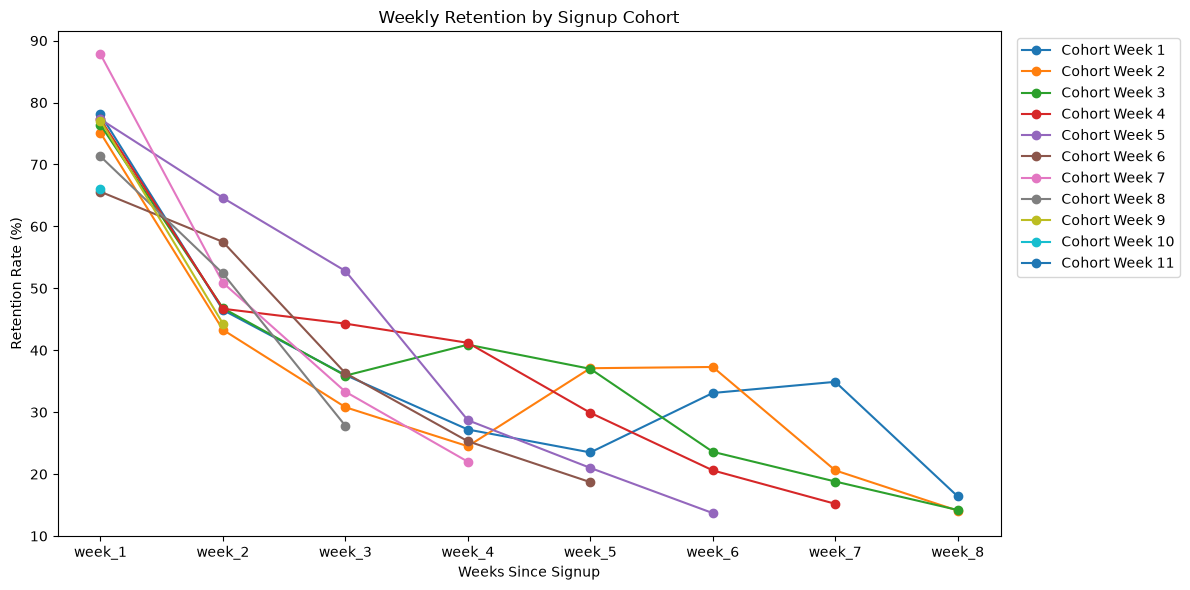

In [163]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

for _, row in retention_pct.iterrows():
    ax.plot(week_cols, row[week_cols], marker='o', label=f"Cohort Week {int(row['cohort'])}")

ax.set_xlabel("Weeks Since Signup")
ax.set_ylabel("Retention Rate (%)")
ax.set_title("Weekly Retention by Signup Cohort")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

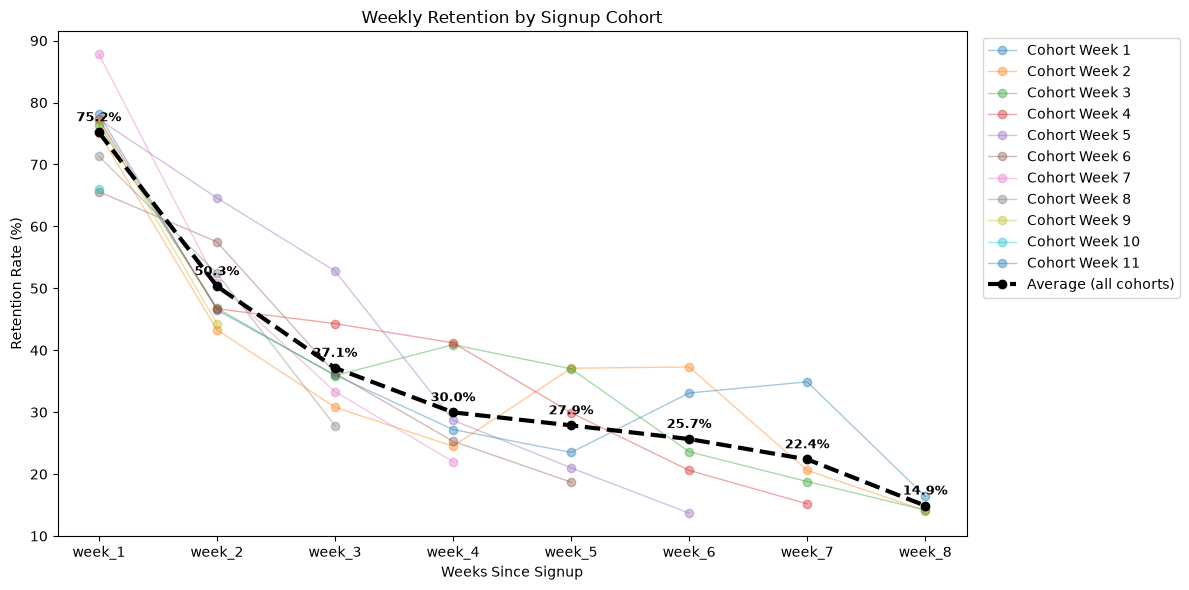

In [165]:
import matplotlib.pyplot as plt

avg_retention = retention_pct[week_cols].mean()

fig, ax = plt.subplots(figsize=(12, 6))

for _, row in retention_pct.iterrows():
    ax.plot(week_cols, row[week_cols], marker='o', alpha=0.4, linewidth=1,
            label=f"Cohort Week {int(row['cohort'])}")

ax.plot(week_cols, avg_retention, marker='o', linewidth=3, color='black',
        linestyle='--', label='Average (all cohorts)', zorder=5)

for week, val in avg_retention.items():
    if not pd.isna(val):
        ax.annotate(f"{val:.1f}%", xy=(week, val),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=9, fontweight='bold', color='black')

ax.set_xlabel("Weeks Since Signup")
ax.set_ylabel("Retention Rate (%)")
ax.set_title("Weekly Retention by Signup Cohort")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

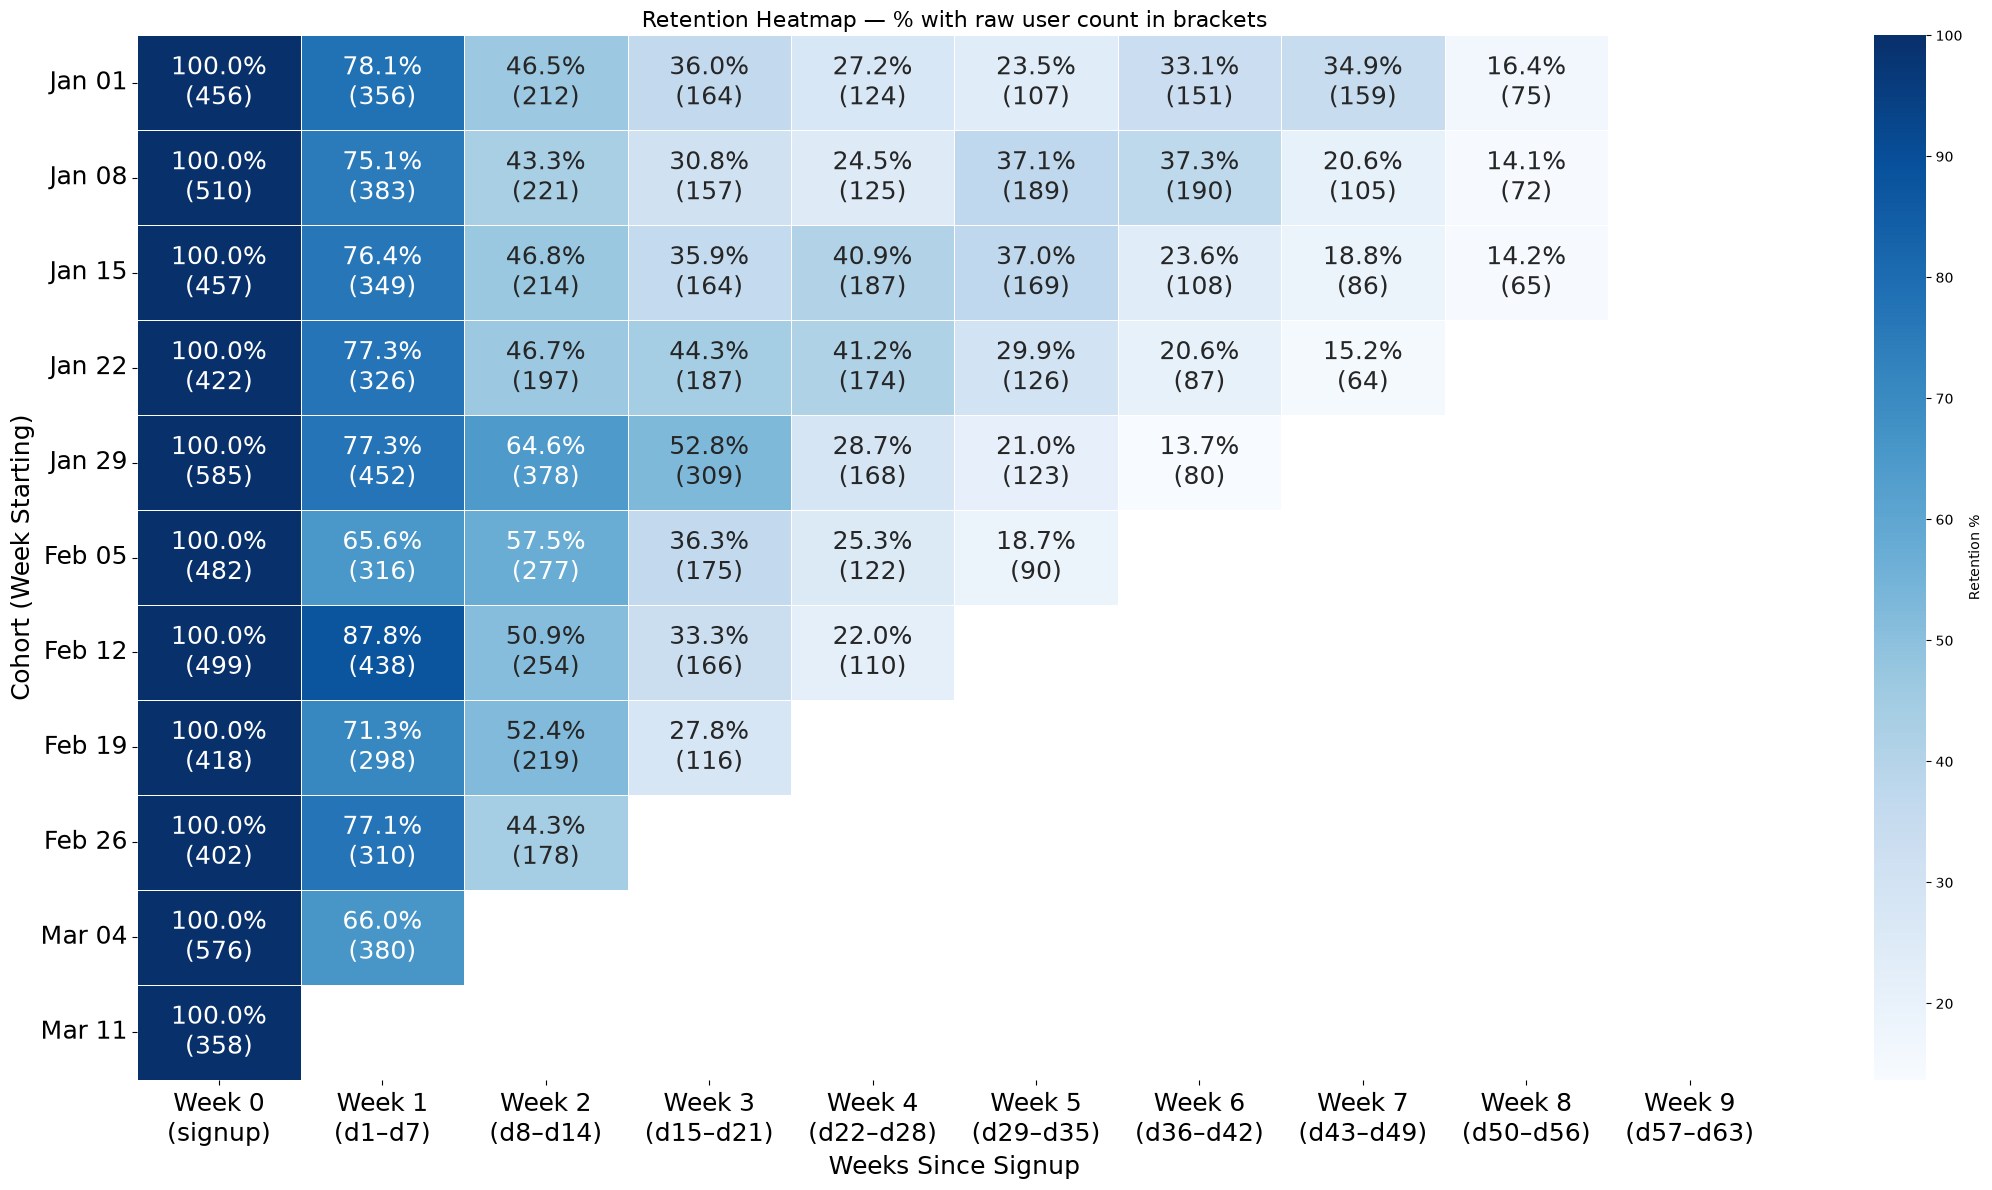

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# map cohort week number → date label
cohort_weeks = nweek_retention["cohort"].astype(int).tolist()
cohort_labels = {
    w: pd.to_datetime(f"2024-{w}-1", format="%Y-%W-%w").strftime("%b %d")
    for w in cohort_weeks
}

# build base tables fresh each run
raw_heat = nweek_retention.set_index("cohort")[week_cols].replace(0, float("nan")).copy()
raw_heat.insert(0, "week_0", nweek_retention.set_index("cohort")["total"])

pct_heat = retention_pct.set_index("cohort")[week_cols].copy()
pct_heat.insert(0, "week_0", 100.0)

all_cols = ["week_0"] + week_cols

# column labels showing week ranges
def week_range_label(col):
    n = int(col.split("_")[1])
    if n == 0:
        return "Week 0\n(signup)"
    start = (n - 1) * 7 + 1
    end = n * 7
    return f"Week {n}\n(d{start}–d{end})"

col_labels = [week_range_label(c) for c in all_cols]

# build combined annotation: "X%\n(N)"
annot = pct_heat.copy().astype(object)
for col in all_cols:
    for idx in pct_heat.index:
        pct_val = pct_heat.loc[idx, col]
        raw_val = raw_heat.loc[idx, col]
        if pd.isna(pct_val):
            annot.loc[idx, col] = ""
        else:
            annot.loc[idx, col] = f"{pct_val:.1f}%\n({int(raw_val)})"

fig, ax = plt.subplots(figsize=(22, 12))

sns.heatmap(pct_heat, ax=ax, cmap="Blues", annot=annot, fmt="",
            linewidths=0.5, annot_kws={"size": 18},
            cbar_kws={"label": "Retention %"})

ax.set_yticklabels([cohort_labels[w] for w in cohort_weeks], rotation=0, fontsize=18)
ax.set_xticklabels(col_labels, rotation=0, ha='center', fontsize=18)
ax.set_title("Retention Heatmap — % with raw user count in brackets", fontsize=16)
ax.set_xlabel("Weeks Since Signup", fontsize=18)
ax.set_ylabel("Cohort (Week Starting)", fontsize=18)

plt.tight_layout()
plt.show()

In [ ]:
## insights : "week 5 and 10 saw high initial signups "; 
# "cohort 7 saw high retention in week 1 did we change anything in 
# "the product ? specifically for new users ?" ;  "similarly for cohort 5 & 6  in week 3"
# "did soething happen in week 7 - the feb 12th week were we running valentines offer ?"


# Cohort Retention Analysis — Interpretation Notes
### FitTrack Product Analyst Case Study

---

## 1. General Framework: How to Read Any Cohort Retention Heatmap

A reusable checklist for interpreting cohort retention tables in interviews or on the job.

| Step | What to look at | What it tells you |
|---|---|---|
| 1. Read down the first data column (week_1) | Compare week_1 % across all cohorts | Onboarding / first-session quality. Tight band = consistent experience. One outlier row = something specific happened that week. |
| 2. Read across a single row | Trend of one cohort over time | That cohort's decay curve. Should generally trend downward. A row that goes back up mid-way breaks the expected shape — worth investigating, not ignoring. |
| 3. Read down a fixed week-number column | Same week N across all cohorts | Whether "week N" is inherently a strong/weak point in the product lifecycle (e.g. "everyone drops after week 2 because the free trial ends"). |
| 4. Cross-check anomalies against the calendar | Convert week N back to an actual date per cohort | Separates "signup-cohort effects" from "calendar/seasonal effects." If different cohorts spike at *different* week numbers but the *same calendar date*, it's an external event, not a cohort-quality signal. |
| 5. Classify the anomaly | Isolated vs. widespread | One row/cell off, rest normal → cohort-specific/operational issue (bug, outage). Many cohorts off at the same calendar time → seasonal/company-wide event (launch, campaign, holiday). Same pattern repeating at the same relative week across most cohorts → genuine product lifecycle behavior. |
| 6. Always ask "so what" | Before reporting any number | Is it good/bad vs. other cohorts/channels? Improving or worsening over time? What decision would this number change? |

**Core discipline:** numbers are data points — the interview-worthy skill is finding the pattern (or the break in the pattern) and explaining *why* it's there, not just reporting the percentage.

---

## 2. Specific Findings From This Analysis

### Finding 1 — Baseline decay curve (expected pattern)
**Observation:** Across nearly all cohorts, retention follows: ~100% (week 0) → 65-88% (week 1) → 43-65% (week 2) → gradual decline afterward, flattening into the teens/twenties by week 7-8.

**Interpretation:** This is a standard, healthy-looking retention shape for a consumer app — most churn happens early (users who don't form a habit leave fast), and a smaller core group sticks around and decays more slowly. Not itself a red flag; it's the baseline against which you compare specific cohorts.

**What I'd say in an interview:**
> "The overall shape follows the typical early-drop-then-plateau curve you'd expect for a consumer fitness app — most attrition happens in the first two weeks, consistent with users who never form a workout habit leaving quickly."

---

### Finding 2 — Isolated cohort anomaly (Feb 05 cohort)
**Observation:** Feb 05 cohort's week_1 retention is **65.6%**, while every neighboring cohort (Jan 29: 77.3%, Feb 12: 87.8%) sits 10-20 points higher. No gradual buildup or decline around it — it's a sharp, single-cohort dip specifically at week 1.

**Possible reasons (hypotheses to raise, not conclusions to assert):**
- An app bug, crash, or broken onboarding flow specific to that signup week
- A backend outage or downtime event during that week
- A bad batch of signups from a specific campaign that skewed toward lower-intent users
- A push notification / reminder system failure that week (users who'd normally get a nudge to return didn't)

**Why it's cohort-specific, not a channel or seasonal issue:** the dip is isolated to one signup week and shows up immediately at week 1, cutting across whatever channel mix that cohort had — a channel-quality problem would show up more gradually and repeatedly across multiple cohorts from that channel, not as a single-week cliff.

**What I'd say in an interview:**
> "Feb 5's cohort shows a week-1 retention roughly 15 points below trend, with no gradual ramp — that pattern points to something operational that week specifically, like an onboarding bug or outage, rather than a change in acquisition quality. I'd want to check engineering incident logs or app store reviews from that week before concluding anything."

---

### Finding 3 — Calendar-aligned engagement bump (mid-February)
**Observation:** Several *different* cohorts show unexpected upward bumps in retention, but the bumps land at *different* relative week numbers:
- Jan 01 cohort bumps at week_6/week_7 (33.1% / 34.9%)
- Jan 08 cohort bumps at week_5/week_6 (37.1% / 37.3%)
- Jan 29 cohort bumps at week_2 (64.6%, unusually high)
- Feb 12 cohort's week_1 is the highest in the table (87.8%)

When mapped back to actual calendar dates (cohort start date + week number), **all of these bumps land in roughly the same real-world window — mid-to-late February.**

**Possible reasons (hypotheses to raise):**
- A feature launch or app update released in mid-February that re-engaged existing users across all cohorts
- A marketing push, in-app promo, or challenge/event (e.g. a "February fitness challenge") that boosted activity company-wide
- A seasonal effect — e.g. New Year's resolution users who lapsed in early Feb coming back for a mid-month reset, or a broader seasonal fitness trend
- Could also be a measurement artifact (e.g. a change in how activity was logged/tracked around that date) — worth ruling out before trusting it as real engagement

**Why this is a calendar effect, not a cohort-quality signal:** if it were about cohort quality (e.g. "cohorts from late January are just better"), the bump would show up at the *same relative week* for each cohort. Instead, it shows up at *different* relative weeks but the *same calendar date* — the hallmark of an external, time-bound event.

**What I'd say in an interview:**
> "I noticed several cohorts show a retention bump, but at different points in their individual lifecycle — which ruled out a cohort-quality explanation. When I mapped week number back to calendar date, all the bumps clustered around mid-February, suggesting a company-wide event — a launch, campaign, or seasonal effect — rather than something about those specific cohorts. I'd flag this to product/marketing to confirm what happened, and I wouldn't bake this bump into a forward-looking retention forecast unless we know it's repeatable."

---

## 3. How This Connects to the Business Ask (FitTrack / Series B framing)

> "Retention decay is broadly consistent and healthy-looking across cohorts, with two notable exceptions: an isolated operational dip in the Feb 5 cohort worth a quick engineering/incident check, and a mid-February engagement bump affecting multiple cohorts simultaneously that looks calendar-driven rather than cohort-driven. For the Series B retention narrative, I'd exclude the mid-Feb bump from baseline projections unless we can confirm and repeat whatever caused it — otherwise we risk overstating steady-state retention to investors."

---

## 4. Interview Framing Tips 

- **Lead with the pattern, not the number.** "Retention drops sharply in week 1-2 then stabilizes" is a better opening line than "week 1 is 78%, week 2 is 46%..."
- **Always propose a hypothesis, but flag it as unconfirmed.** Interviewers want to see structured reasoning ("this could be X, Y, or Z — here's how I'd check"), not a guess stated as fact.
- **Show you checked calendar time vs. relative time.** This is a genuinely differentiating instinct — many candidates only look at week-since-signup and miss calendar-driven effects entirely.
- **Distinguish "isolated" vs. "widespread" anomalies out loud.** It signals you know these imply different root causes and different next actions (an isolated dip → check ops/engineering; a widespread bump → check product/marketing calendar).
- **Close with a business implication**, not just an observation — this is what separates a PA answer from a purely analytical one.